In [188]:
# AIRCRAFT TIRE CONTACT STRESS GENERATOR
# =============================================================================
# Reference: Airfield Pavement Response Caused by Heavy Aircraft Takeoff
# Hernandez & AL-Qadi, 2015 (TRB)
# =============================================================================
# This notebook computes tire contact stresses and exports results to Excel.
# Improvements: code structure, comments, folder organization, and efficiency.
# =============================================================================

# --- Imports ---
import os
import time
import numpy as np
import pandas as pd
import xlsxwriter
from openpyxl import load_workbook
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize, TwoSlopeNorm

# --- Folder Setup ---
INPUT_DIR = 'input_data'
OUTPUT_DIR = 'output'
if not os.path.exists(INPUT_DIR):
    os.makedirs(INPUT_DIR)
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- Utility Functions ---
def clear_terminal():
    os.system('cls' if os.name == 'nt' else 'clear')

clear_terminal()

# --- Timing ---
start = time.time()

# --- Input Parameters ---
P = 153463.65  # Load, [N]
l = 380.0      # Contact length [mm]
TiP = 1.379    # Tire inflation pressure [MPa]
Tire = 'P1'    # Load label, for file naming
RC = 'FR'      # Rolling condition, FR = Free-Rolling

# Contact geometry and stress factors
bi = [50.0, 35.0, 40., 90.0, 40.0, 35.0, 50.0]  # Contact width per rib [mm]
al = [0.24, 0.08, 0.08, 0.20, 0.08, 0.08, 0.24]  # Load carried by each rib
sigm_Tip = [1.8, 1.1, 1.1, 1.1, 1.1, 1.1, 1.8]  # Max vert stress factor per rib [MPa]
ssy_factor = 0.4  # SSY = ssy_factor*SSZ
nz = [2, 2, 2, 2, 2, 2, 2]  # Partitions per rib
l_elem = 38.0  # Element length [mm]

xn = l / l_elem    # Number of elements in contact length

# Arrays represeting the position of each node along the contact length
xloc = [(l_elem * i) - (l / 2.0) for i in range(int(xn) + 1)]
xnorm = [((l_elem * i) - (l / 2.0)) / (l / 2.0) for i in range(int(xn) + 1)]
xdist = [(l_elem * i) for i in range(int(xn) + 1)]

# Skewed parabola parameters for longitudinal stresses
lsx_pospk = 0.20
lsx_negpk = 0.85
sx_posmag = 0.20
sx_negmag = -0.15
skpb = 0.60
ssx_cut = xdist[int(round(skpb * len(xdist)))]

# Output Excel file name
xlname = os.path.join(OUTPUT_DIR, f'B787.xlsx')

# Percent diff threshold for equilibrium
pdiff = 5

# =============================================================================
# --- Main Calculations ---
# =============================================================================
# 1. Vertical contact stresses (SSZ)
SSZ = {}
for i, (a, b, s) in enumerate(zip(al, bi, sigm_Tip)):
    n = abs(1.0 / (2.0 * (((l * b * s * TiP) / (a * P)) - 1.0)))
    sz = [((a * P) / (l * b)) * (1.0 + (1.0 / (2.0 * n))) * (1 - (x ** 2.0) ** n) for x in xnorm]
    SSZ[f'Rib {i+1}'] = sz

# 2. Longitudinal contact stresses (SSX)
SSX = {}
x1 = [0, skpb * l]
x2 = [lsx_pospk * l, lsx_negpk * l]
x3 = [skpb * l, l]
y2 = [sx_posmag, sx_negmag]
a3 = [(x1[i] + x3[i] - (2.0 * x2[i])) / (x1[i] * x3[i] - (x2[i] ** 2.0)) for i in range(len(x1))]
a0 = [(-x1[i] * x3[i] * (a3[i] * x2[i] - 1) * y2[i]) / ((x1[i] - x2[i]) * (x3[i] - x2[i])) for i in range(len(x1))]
a1 = [((x1[i] + x3[i]) * (a3[i] * x2[i] - 1) * y2[i]) / ((x1[i] - x2[i]) * (x3[i] - x2[i])) for i in range(len(x1))]
a2 = [(y2[i] - a3[i] * x2[i] * y2[i]) / ((x1[i] - x2[i]) * (x3[i] - x2[i])) for i in range(len(x1))]
for i, (a, s) in enumerate(zip(al, sigm_Tip)):
    sx = []
    for j, x in enumerate(xdist):
        k = 0 if 0 <= x <= ssx_cut else 1
        sx.append(TiP * s * ((a2[k] * (x ** 2.0) + a1[k] * x + a0[k]) / (1.0 - (a3[k] * x))))
    SSX[f'Rib {i+1}'] = sx

# 3. Transverse contact stresses (SSY)
SSY = {f'Rib {i+1}': [ssy_factor * v for v in SSZ[f'Rib {i+1}']] for i in range(len(al))}

# 4. Average contact stresses for Abaqus input
axdist = [(xdist[i] + xdist[i + 1]) / 2.0 for i in range(int(xn))]

asz, asx, asy = {}, {}, {}
dfasz, dfasx, dfasy = {}, {}, {}
Eq_Pz = []
for i in range(len(al)):
    rib = f'Rib {i+1}'
    asz[rib] = [(SSZ[rib][j] + SSZ[rib][j + 1]) / 2.0 for j in range(int(xn))]
    asx[rib] = [(SSX[rib][j] + SSX[rib][j + 1]) / 2.0 for j in range(int(xn))]
    asy[rib] = [(SSY[rib][j] + SSY[rib][j + 1]) / 2.0 for j in range(int(xn))]
    sum_sz = []
    for j in range(nz[i]):
        # DataFrames for each stress type
        dfasz['coordX SSZ'] = axdist
        dfasz[f'{rib}_{j+1}'] = asz[rib]
        dfasx['coordX SSX'] = axdist
        dfasx[f'{rib}_{j+1}'] = asx[rib]
        dfasy['coordX SSY'] = axdist
        # Partition logic for transverse stresses
        if nz[i] == 4:
            if j == 0:
                dfasy[f'{rib}_{j+1}'] = asy[rib]
            elif j in [1, 2]:
                dfasy[f'{rib}_{j+1}'] = [0.00001] * len(asy[rib])
            elif j == 3:
                dfasy[f'{rib}_{j+1}'] = [-1.0 * v for v in asy[rib]]
        elif nz[i] == 3:
            if j == 0:
                dfasy[f'{rib}_{j+1}'] = asy[rib]
            elif j == 1:
                dfasy[f'{rib}_{j+1}'] = [0.00001] * len(asy[rib])
            elif j == 2:
                dfasy[f'{rib}_{j+1}'] = [-1.0 * v for v in asy[rib]]
        elif nz[i] == 2:
            if j == 0:
                dfasy[f'{rib}_{j+1}'] = asy[rib]
            elif j == 1:
                dfasy[f'{rib}_{j+1}'] = [-1.0 * v for v in asy[rib]]
        sum_sz.append(sum(np.array(dfasz[f'{rib}_{j+1}'])))
    Eq_Pz.append(sum(sum_sz) * l_elem * (bi[i] / nz[i]))

Calc_Pz = sum(Eq_Pz)
Diff = 100.0 * ((P - Calc_Pz) / P)
print(f'Calc = {Calc_Pz:.2f} kN, Applied = {P:.2f} kN')
print(f'Diff = {Diff:.2f} %')
if Diff > pdiff:
    print(f'Percent difference in calculated and applied load is greater than {pdiff}%!')
else:
    print(f'Equilibrium check passed! Difference is less than {pdiff}%!')

# --- Output to Excel ---
dfasz = pd.DataFrame(dfasz).set_index('coordX SSZ').T
dfasx = pd.DataFrame(dfasx).set_index('coordX SSX').T
dfasy = pd.DataFrame(dfasy).set_index('coordX SSY').T

sheetn = f'{Tire} P{round(P/1000)}kN S{TiP}MPa_{RC}'

# Save to Excel in output folder
with pd.ExcelWriter(xlname, engine='xlsxwriter') as writer:
    workbook = writer.book
    cell_format = workbook.add_format({'bold': True, 'italic': True})
    # Write SSV
    dfasz.to_excel(writer, sheet_name=sheetn, startrow=0)
    worksheet = writer.sheets[sheetn]
    worksheet.write(0, 0, 'SSV [MPa]', cell_format)
    # Write SSX
    start_row = (max(nz) * len(al)) + 2
    dfasx.to_excel(writer, sheet_name=sheetn, startrow=start_row)
    worksheet = writer.sheets[sheetn]
    worksheet.write(start_row, 0, 'SSX [MPa]', cell_format)
    # Write SSY
    start_row = 2 * start_row
    dfasy.to_excel(writer, sheet_name=sheetn, startrow=start_row)
    worksheet = writer.sheets[sheetn]
    worksheet.write(start_row, 0, 'SSY [MPa]', cell_format)

# --- Timing ---
end = time.time()
elapsed = end - start
print(f'Elapsed Time: {elapsed:.2f} seconds.')

Calc = 151847.04 kN, Applied = 153463.65 kN
Diff = 1.05 %
Equilibrium check passed! Difference is less than 5%!
Elapsed Time: 0.12 seconds.


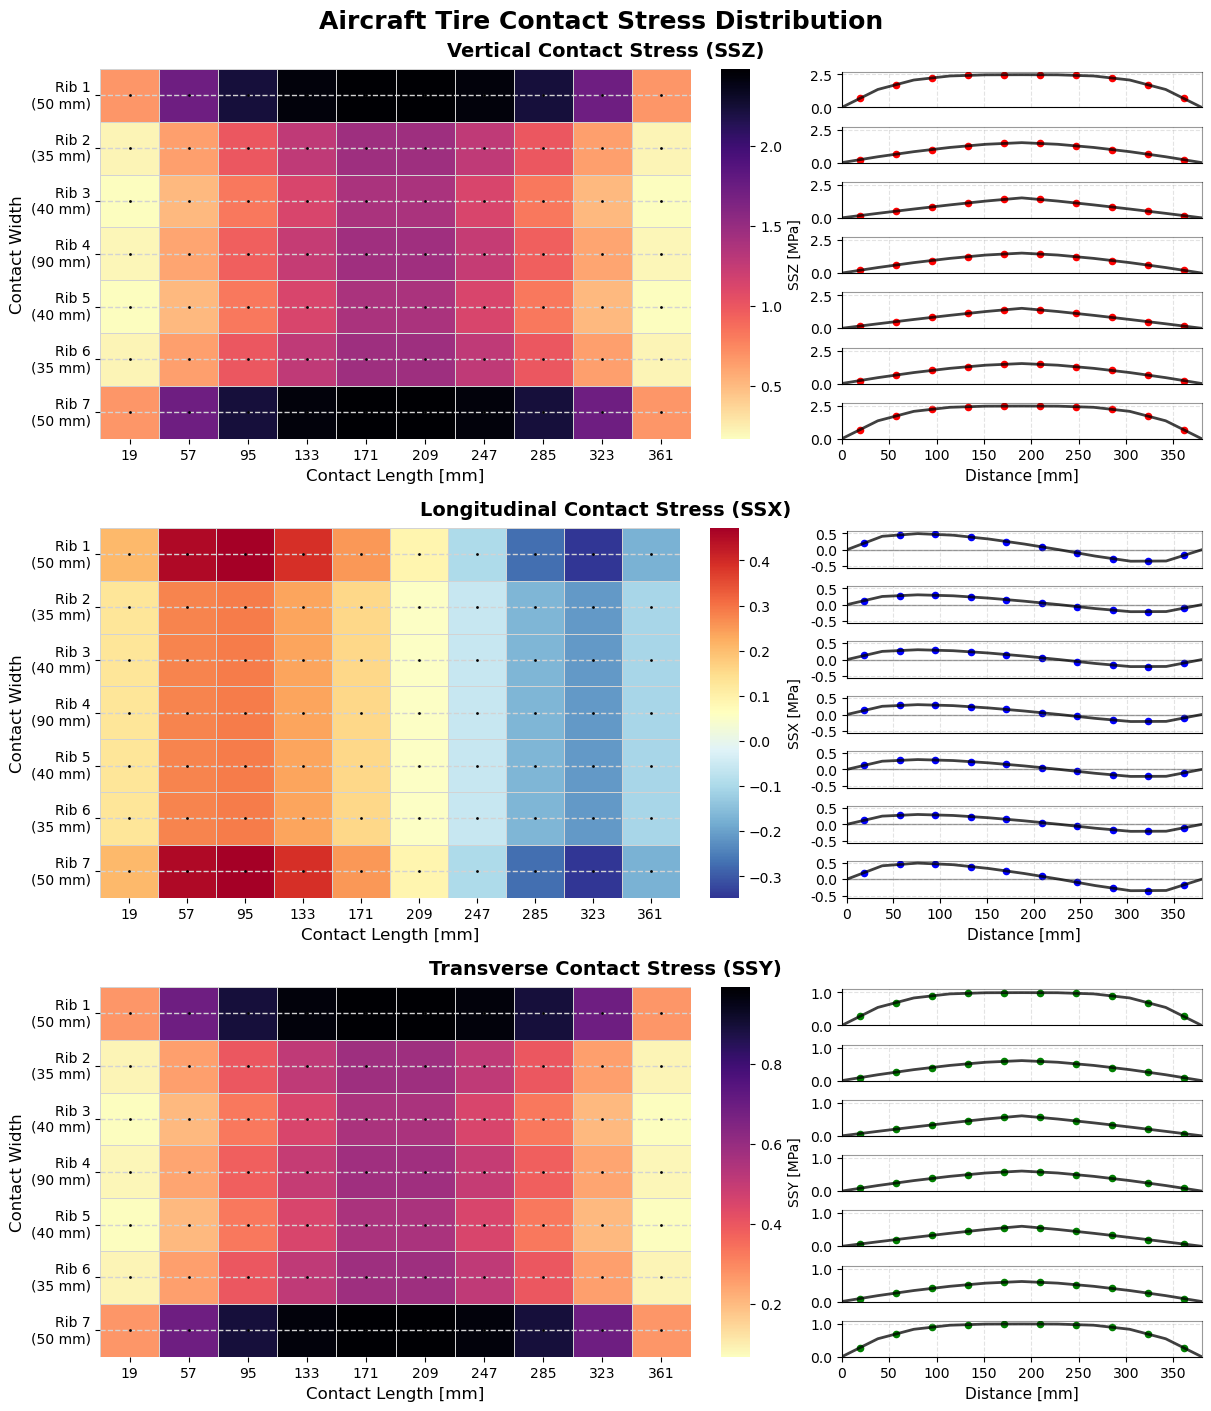

In [189]:
# --- Visualization: Heatmaps + rib-wise comparison plots (aligned) ---
ssz_matrix = np.array([asz[f'Rib {i+1}'] for i in range(len(al))])
ssx_matrix = np.array([asx[f'Rib {i+1}'] for i in range(len(al))])
ssy_matrix = np.array([asy[f'Rib {i+1}'] for i in range(len(al))])

x_labels = [f'{x:.0f}' for x in axdist] 
y_labels = [f'Rib {i+1}\n({bi[i]:.0f} mm)' for i in range(len(bi))]
num_ribs = len(al)

stress_blocks = [
    dict(name="Vertical Contact Stress (SSZ)", mat=ssz_matrix, cmap="magma_r",
         cbar_label="SSZ [MPa]", theory=SSZ, x_scatter=axdist, x_theory=xdist, linecolor="#000000",
         ymode="positive"),
    dict(name="Longitudinal Contact Stress (SSX)", mat=ssx_matrix, cmap="RdYlBu_r",
         cbar_label="SSX [MPa]", theory=SSX, x_scatter=axdist, x_theory=xdist, linecolor="#000000",
         ymode="symmetric"),
    dict(name="Transverse Contact Stress (SSY)", mat=ssy_matrix, cmap="magma_r",
         cbar_label="SSY [MPa]", theory=SSY, x_scatter=axdist, x_theory=xdist, linecolor="#000000",
         ymode="positive"),
]

fig = plt.figure(figsize=(12, 14), dpi=100, layout="constrained")
subfigs = fig.subfigures(nrows=3, ncols=1)  # perfect row-wise alignment


colors = ["red", "blue", "green"]
for idx, block in enumerate(stress_blocks):
    subfig = subfigs[idx]
    subfig.suptitle(block["name"], fontsize=14, fontweight="bold")

    # Two main panels: (heatmap + cbar) | (rib stack)
    gs = subfig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.00, 0.50], wspace=0.20)

    # ---- Left panel: heatmap + dedicated colorbar axis (prevents layout drift) ----
    gs_left = gs[0, 0].subgridspec(1, 2, width_ratios=[20, 1], wspace=0.05)
    ax_hm  = subfig.add_subplot(gs_left[0, 0])
    ax_cbar = subfig.add_subplot(gs_left[0, 1])

    # Center SSX colormap at 0 for better interpretation
    heatmap_kwargs = dict(linewidths=0.5, linecolor="lightgrey", square=False, annot=False)
    if "seismic" in block["cmap"]:
        sns.heatmap(block["mat"], ax=ax_hm, cmap=block["cmap"], center=0.0,
                    cbar=True, cbar_ax=ax_cbar, cbar_kws={"label": block["cbar_label"]},
                    xticklabels=x_labels, yticklabels=y_labels, **heatmap_kwargs)
    else:
        sns.heatmap(block["mat"], ax=ax_hm, cmap=block["cmap"],
                    cbar=True, cbar_ax=ax_cbar, cbar_kws={"label": block["cbar_label"]},
                    xticklabels=x_labels, yticklabels=y_labels, **heatmap_kwargs)

    ax_hm.set_xlabel("Contact Length [mm]", fontsize=12)
    ax_hm.set_ylabel("Contact Width", fontsize=12)
    ax_hm.tick_params(axis="x", rotation=0)
    ax_hm.tick_params(axis="y", rotation=0)

    # Partition lines
    y_pos = 0
    for i, partitions in enumerate(nz):
        for p in range(1, partitions):
            ax_hm.axhline(y=y_pos + p*(1/partitions), color="lightgrey", linestyle="--", linewidth=1)
        y_pos += 1

    # Black points at cell centers
    num_x = block["mat"].shape[1]
    for i in range(num_ribs):
        for j in range(num_x):
            ax_hm.plot(j + 0.5, i + 0.5, marker="o", color="black", markersize=2, markeredgewidth=0)

    ##############################################################
    # ---- Right panel: rib stack (aligned to heatmap height) ----
    gs_right = gs[0, 1].subgridspec(num_ribs, 1, hspace=0.0)

    rib_axes = []
    for rib in range(num_ribs):
        ax_rib = subfig.add_subplot(gs_right[rib, 0], sharex=rib_axes[0] if rib_axes else None)
        rib_axes.append(ax_rib)

    # Consistent y-limits across ribs in this block (makes comparison clean)
    data_min = float(np.min(block["mat"]))
    data_max = float(np.max(block["mat"]))
    if block["ymode"] == "symmetric":
        y_abs = max(abs(data_min), abs(data_max))
        ylims = (-y_abs * 1.20, y_abs * 1.20)
    else:
        ylims = (0.0, data_max * 1.10)

    for rib, ax_rib in enumerate(rib_axes):
        # scatter = averaged (midpoints), theory = node-based curve
        ax_rib.plot(block["x_theory"], block["theory"][f"Rib {rib+1}"],
                    color=block["linecolor"], linestyle="-", alpha=0.75, linewidth=2.0)
        ax_rib.scatter(block["x_scatter"], block["mat"][rib], s=20, color=colors[idx])
        ax_rib.set_xlim(0.0, l)
        ax_rib.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))  ###
        ax_rib.set_ylim(*ylims)

        # Cleaner styling
        ax_rib.grid(True, linestyle="--", alpha=0.35)
        ax_rib.spines["top"].set_alpha(0.4)
        ax_rib.spines["right"].set_alpha(0.4)

        # Only bottom rib shows x tick labels; BUT xlabel always shown for each block (your request)
        if rib != num_ribs - 1:
            ax_rib.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
        else:
            ax_rib.tick_params(axis="x", which="both", bottom=True, labelbottom=True)
            ax_rib.set_xlabel("Distance [mm]", fontsize=11)

        # Remove y-axis label clutter; keep ticks (optional)
        ax_rib.set_ylabel("")

        # Add a subtle zero line for SSX (helps interpret sign)
        if block["ymode"] == "symmetric":
            ax_rib.axhline(0.0, linewidth=1.0, alpha=0.35, color="black")

    # Single legend per block (top rib axis)
    #rib_axes[0].legend(["Theory", "Data"], loc="upper left", frameon=False, fontsize=9)

fig.suptitle("Aircraft Tire Contact Stress Distribution ", fontsize=18, fontweight="bold")
plt.show()


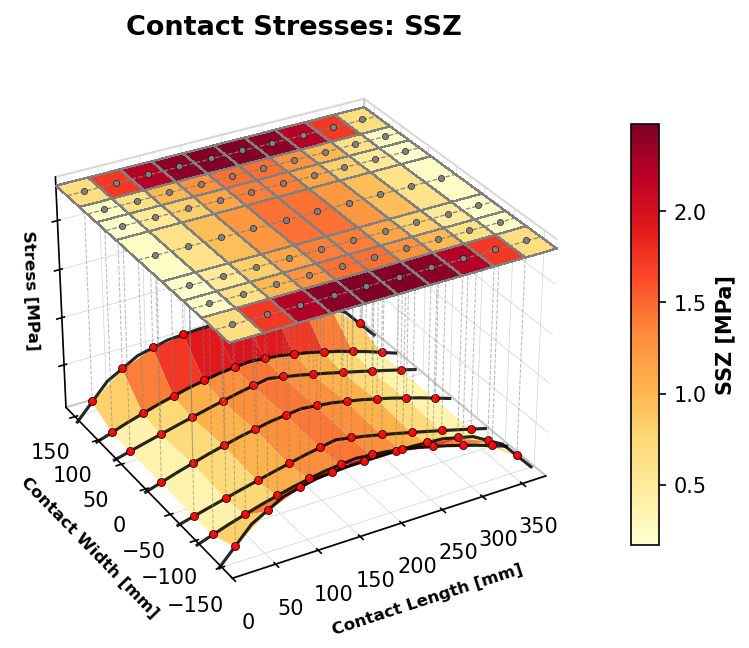

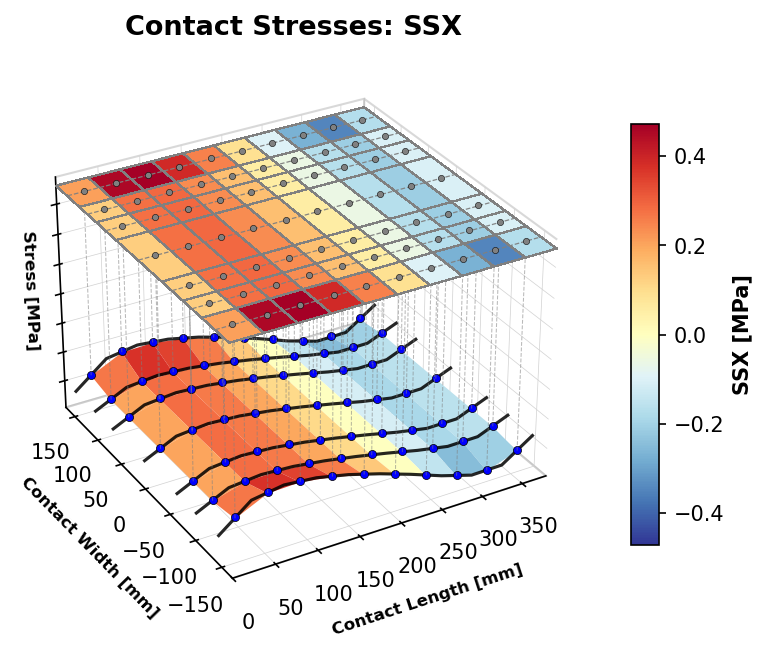

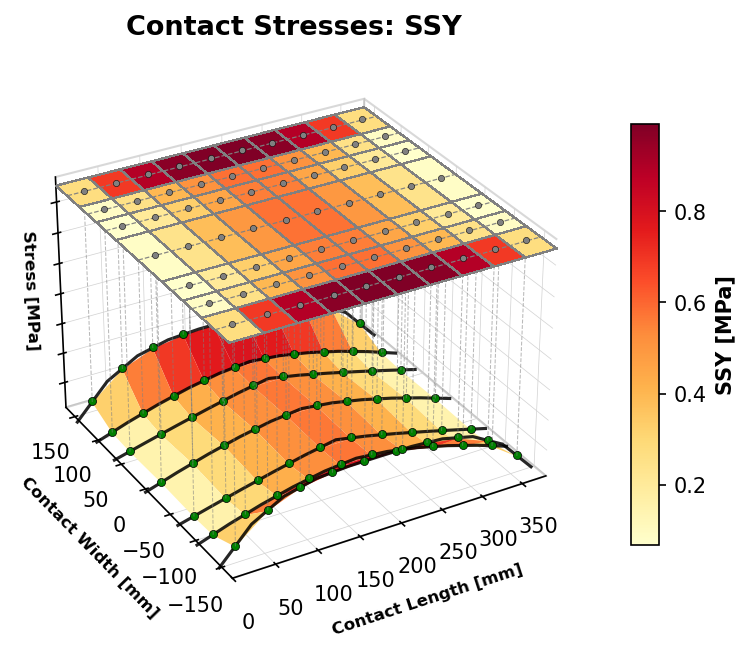

(<Figure size 1050x900 with 2 Axes>,
 <Axes3D: title={'center': 'Contact Stresses: SSY'}, xlabel='Contact Length [mm]', ylabel='Contact Width [mm]', zlabel='Stress [MPa]'>)

In [190]:
def add_3d_heatmap_plane(
    ax,
    Z,                      # (num_ribs, num_x)
    x_mids,                 # axdist (num_x)
    rib_widths,             # bi (num_ribs)
    *,
    cmap,
    norm,
    z_offset,
    nz_partitions=None,     # nz list
    center_width_at_zero=True,
    # grid (cell borders)
    grid_color="grey",
    grid_lw=0.60,
    # black points
    add_points=True,
    dot_color="grey",
    marker_size=0.5,        # marker size in points
    # dashed partition lines
    add_partitions=True,
    dash_color="grey",
    dash_lw=0.60,
    dash_ls="--",
):
    Z = np.asarray(Z, float)

    # --- x edges from midpoints ---
    x_mids = np.asarray(x_mids, float)
    dx = np.diff(x_mids)
    if len(dx) == 0:
        raise ValueError("x_mids must have at least 2 points.")
    dx0, dx1 = dx[0], dx[-1]
    x_edges = np.r_[x_mids[0] - dx0/2, 0.5*(x_mids[:-1] + x_mids[1:]), x_mids[-1] + dx1/2]

    # --- y edges from rib widths ---
    rib_widths = np.asarray(rib_widths, float)
    y_edges = np.r_[0.0, np.cumsum(rib_widths)]
    if center_width_at_zero:
        y_edges = y_edges - 0.5 * y_edges[-1]
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    # --- quad grid for plane (edges) ---
    Xe, Ye = np.meshgrid(x_edges, y_edges)          # (nribs+1, nx+1)
    Ze = np.full_like(Xe, float(z_offset))

    facecolors = cmap(norm(Z))                      # (nribs, nx, 4)

    # Draw flat heatmap plane with borders
    plane = ax.plot_surface(
        Xe, Ye, Ze,
        facecolors=facecolors,
        rstride=1, cstride=1,
        shade=False,                 # keep colors true
        linewidth=grid_lw,
        edgecolor=grid_color,
        antialiased=False
    )
    plane.set_zorder(50)
    try: plane.set_sort_zpos(+1e9)
    except Exception: pass

    # lift overlays slightly above plane to avoid z-fighting
    z_span = float(np.nanmax(Z) - np.nanmin(Z))
    z_lift = max(1e-3, 0.02 * z_span)
    z_pts = z_offset + z_lift
    z_ln  = z_offset + 0.5 * z_lift

    # --- Black points at cell centers (robust: Line3D markers) ---
    if add_points:
        for yc in y_centers:
            dots=ax.plot(
                x_mids,
                np.full_like(x_mids, yc),
                np.full_like(x_mids, z_pts),
                linestyle="None",
                marker="o",
                markersize=marker_size,
                markerfacecolor=dot_color,
                markeredgecolor="black",
                markeredgewidth=0.25,
                zorder=60
            )


    # --- Dashed partition lines inside each rib band (nz) ---
    if add_partitions and (nz_partitions is not None):
        for rib_i, parts in enumerate(nz_partitions):
            if parts <= 1:
                continue
            y0, y1 = y_edges[rib_i], y_edges[rib_i + 1]
            for p in range(1, parts):
                yp = y0 + (p / parts) * (y1 - y0)
                ax.plot(
                    [x_edges[0], x_edges[-1]],
                    [yp, yp],
                    [z_ln, z_ln],
                    color=dash_color,
                    linestyle=dash_ls,
                    linewidth=dash_lw,
                    alpha=0.95,
                    zorder=55
                )

    return plane


def plot_surface_with_heatmap_and_rib_overlays(
    stress_matrix,
    x_mids,
    rib_widths,
    nz_partitions,
    *,
    stress_name="Stress",
    cmap="magma_r",
    symmetric=False,                 # True for SSX
    center_width_at_zero=True,

    # ---- NEW: plane separation control ----
    plane_gap_factor=0.60,           # gap = factor * stress_range (MPa)

    # ---- NEW: per-rib overlays on the bottom surface ----
    theory_dict=None,                # dict like SSZ/SSX/SSY with keys 'Rib 1', ...
    x_theory=None,                   # x locations for theory curves (nodes)
    scatter_color="tab:red",
    line_color="grey",
    overlay_linewidth=1.5,
    overlay_marker_size=15,          # scatter size for midpoints
    overlay_z_lift_factor=0.015,     # lift overlays off surface (fraction of stress range)

    elev=30,
    azim=240,
    figsize=(7, 6),
    dpi=150, 
    add_projection_lines=True,
    proj_stride=1,                 # 1 = every point, 2 = every other point, etc.
    proj_color="grey",
    proj_lw=0.50,
    proj_ls="--",
    proj_alpha=0.55,
):
    
    Z = np.array(stress_matrix, dtype=float)
    x_mids = np.asarray(x_mids, dtype=float)
    rib_widths = np.asarray(rib_widths, dtype=float)

    # Y centers from widths
    y_edges = np.r_[0.0, np.cumsum(rib_widths)]
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    if center_width_at_zero:
        y_centers = y_centers - 0.5 * y_edges[-1]

    # Mesh for surface (centers)
    X, Y = np.meshgrid(x_mids, y_centers)

    # Normalization
    if symmetric:
        vmax = float(np.nanmax(np.abs(Z)))
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        vmin_plot, vmax_plot = -vmax, vmax
    else:
        vmin_plot = float(np.nanmin(Z))
        vmax_plot = float(np.nanmax(Z))
        norm = Normalize(vmin=vmin_plot, vmax=vmax_plot)

    z_range = float(vmax_plot - vmin_plot) if (vmax_plot - vmin_plot) != 0 else 1.0

    fig = plt.figure(figsize=figsize, dpi=dpi, constrained_layout=False)
    ax = fig.add_subplot(111, projection="3d")
    ax.computed_zorder = False 

    # Bottom surface
    surf = ax.plot_surface(
        X, Y, Z,
        cmap=cmap, norm=norm,
        rstride=1, cstride=1,
        linewidth=0.0,
        antialiased=True
    )
    surf.set_zorder(1)
    try: surf.set_sort_zpos(-1e9)
    except Exception: pass
    

    # --- Place the top heatmap plane ABOVE the surface with more separation ---
    z_offset = float(np.nanmax(Z)) + plane_gap_factor * z_range

    add_3d_heatmap_plane(
        ax,
        Z=Z,
        x_mids=x_mids,
        rib_widths=rib_widths,
        cmap=plt.get_cmap(cmap),
        norm=norm,
        z_offset=z_offset,
        nz_partitions=nz_partitions,
        center_width_at_zero=center_width_at_zero,
        add_points=True,
        marker_size=3.0,          # tweak 3–6
        add_partitions=True
    )
    
    if add_projection_lines:
        from mpl_toolkits.mplot3d.art3d import Line3DCollection

        # Match the same top-dot lift logic used in add_3d_heatmap_plane
        z_span = float(np.nanmax(Z) - np.nanmin(Z))
        z_lift = max(1e-3, 0.02 * z_span)     # same as in add_3d_heatmap_plane
        z_top  = z_offset + z_lift

        # tiny lift off the surface so lines don't z-fight with the surface polygons
        z_bot_lift = max(1e-3, 0.01 * z_span)

        segs = []
        nr, nx = Z.shape
        for i in range(0, nr, proj_stride):
            y = y_centers[i]
            for j in range(0, nx, proj_stride):
                z0 = Z[i, j]
                if not np.isfinite(z0):
                    continue
                x = x_mids[j]
                segs.append([(x, y, z0 + z_bot_lift), (x, y, z_top)])

        proj = Line3DCollection(
            segs,
            colors=proj_color,
            linewidths=proj_lw,
            linestyles=proj_ls,
            alpha=proj_alpha
        )
        proj.set_zorder(40)  # draw late so it's visible
        ax.add_collection3d(proj)
    
    # --- Overlay: per-rib theory curves + midpoint scatters ON THE BOTTOM surface ---
    if (theory_dict is not None) and (x_theory is not None):
        x_theory = np.asarray(x_theory, dtype=float)

        # If theory x is centered around 0 (e.g., -L/2..L/2) but mids are 0..L, shift it
        # Build x_edges from mids to infer left edge ~0
        dx = np.diff(x_mids)
        x_left = x_mids[0] - dx[0]/2
        if (x_theory.min() < 0) and (x_left >= 0):
            x_theory = x_theory + (x_left - x_theory.min())

        z_lift = overlay_z_lift_factor * z_range

        for rib_i, yc in enumerate(y_centers):
            rib_key = f"Rib {rib_i+1}"
            if rib_key not in theory_dict:
                continue

            z_line = np.asarray(theory_dict[rib_key], dtype=float) + z_lift
            line = ax.plot(
                x_theory,
                np.full_like(x_theory, yc),
                z_line,
                color=line_color,
                linewidth=overlay_linewidth,
                alpha=0.85
            )[0]
            line.set_zorder(2)
            

            z_sc = Z[rib_i, :] + 1.5 * z_lift
            sc = ax.scatter(
                x_mids,
                np.full_like(x_mids, yc),
                z_sc,
                s=overlay_marker_size,
                c=scatter_color,
                edgecolors="black",
                linewidths=0.35,
                depthshade=False
            )
            sc.set_zorder(3)

    # Colorbar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.55, aspect=15, pad=0.08)
    cbar.set_label(f"{stress_name} [MPa]", fontweight="bold", fontsize=10)
    cbar.ax.tick_params(labelsize=10)
    
    # Labels
    ax.set_xlabel("Contact Length [mm]", fontweight="bold", fontsize=8, labelpad=4)
    ax.set_ylabel("Contact Width [mm]",  fontweight="bold", fontsize=8, labelpad=4)
    ax.set_zlabel("Stress [MPa]",        fontweight="bold", fontsize=8, labelpad=-12, rotation=90)
    
    ax.zaxis.set_tick_params(label1On=False)

    dx = np.diff(x_mids)
    if len(dx) == 0:
        raise ValueError("x_mids must have at least 2 points.")
    x_edges = np.r_[x_mids[0] - dx[0]/2,
                    0.5*(x_mids[:-1] + x_mids[1:]),
                    x_mids[-1] + dx[-1]/2]

    y_edges = np.r_[0.0, np.cumsum(rib_widths)]
    if center_width_at_zero:
        y_edges = y_edges - 0.5 * y_edges[-1]

    # Limits + view (headroom so plane/overlays never clip)
    ax.set_xlim(float(x_edges[0]), float(x_edges[-1]))
    ax.set_ylim(float(y_edges[0]), float(y_edges[-1]))
    ax.set_zlim(vmin_plot, z_offset + 0.15 * z_range)

    ax.view_init(elev=elev, azim=azim)
    
    fig.subplots_adjust(left=0.26, right=0.95, bottom=0.10, top=0.95)
    ax.yaxis.set_label_coords(0.02, 0.5) 

    # Clean panes/grid
    ax.grid(True)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo["grid"].update(color="lightgrey", linestyle="-", linewidth=0.35)
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.set_facecolor((1, 1, 1, 0.0))
        pane.set_edgecolor((0.7, 0.7, 0.7, 0.5))

    ax.set_title(f"Contact Stresses: {stress_name}", fontweight="bold", fontsize=13, pad=10)
    plt.show()

    return fig, ax

# ----------------- Calls (use your existing variables) -----------------
# SSZ theory uses xloc (often -L/2..L/2) -> function auto-shifts to 0..L
plot_surface_with_heatmap_and_rib_overlays(
    ssz_matrix, axdist, bi, nz,
    stress_name="SSZ", cmap="YlOrRd", symmetric=False,
    theory_dict=SSZ, x_theory=xloc,
    scatter_color="red", line_color="black",
    plane_gap_factor=3.00
)

plot_surface_with_heatmap_and_rib_overlays(
    ssx_matrix, axdist, bi, nz,
    stress_name="SSX", cmap="RdYlBu_r", symmetric=True,
    theory_dict=SSX, x_theory=xdist,
    scatter_color="blue", line_color="black",
    plane_gap_factor=3.00
)

plot_surface_with_heatmap_and_rib_overlays(
    ssy_matrix, axdist, bi, nz,
    stress_name="SSY", cmap="YlOrRd", symmetric=False,
    theory_dict=SSY, x_theory=xloc,
    scatter_color="green", line_color="black",
    plane_gap_factor=3.00
)
